# Tennis Match Analysis
## First Set Advantage: Does Winning the First Set Guarantee Victory?

This notebook investigates the relationship between winning the first set and match outcome in ATP tennis. We analyze whether first-set dominance is a reliable predictor of match victory.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast  # For literal_eval to parse strings that look like lists



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pbp_id              9871 non-null   int64 
 1   date                9871 non-null   object
 2   tny_name            9871 non-null   object
 3   tour                9871 non-null   object
 4   draw                9871 non-null   object
 5   server1             9871 non-null   object
 6   server2             9871 non-null   object
 7   winner              9871 non-null   int64 
 8   pbp                 9871 non-null   object
 9   score               9871 non-null   object
 10  adf_flag            9871 non-null   int64 
 11  wh_minutes          9871 non-null   int64 
 12  score_winner_valid  9871 non-null   bool  
 13  pbp_fixed           9871 non-null   object
 14  pbp_set_count       9871 non-null   int64 
 15  score_set_count     9871 non-null   int64 
 16  set_count_match     9871

## 1. Data Loading and Inspection
Load the cleaned dataset and perform initial exploratory analysis.

In [ ]:

df = pd.read_csv('Cleaned_dataset.csv')


print(df.info()) 
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8980 entries, 0 to 8979
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pbp_id              8980 non-null   int64 
 1   date                8980 non-null   object
 2   server1             8980 non-null   object
 3   server2             8980 non-null   object
 4   winner              8980 non-null   int64 
 5   pbp                 8980 non-null   object
 6   score               8980 non-null   object
 7   wh_minutes          8980 non-null   int64 
 8   score_winner_valid  8980 non-null   bool  
 9   pbp_fixed           8980 non-null   object
 10  pbp_set_count       8980 non-null   int64 
 11  score_set_count     8980 non-null   int64 
 12  set_count_match     8980 non-null   bool  
 13  pbp_set_winners     8980 non-null   object
 14  set_match           8980 non-null   bool  
 15  pbp_match_winner    8980 non-null   int64 
 16  winner_match        8980

## 2. Data Validation and Cleaning
Ensure data quality by filtering for reasonable match durations and valid dates.

### Filters Applied:
- **Duration**: 30–500 minutes (removes outliers)
- **Date Format**: Coerce invalid dates to NaT
- **Missing Values**: Drop rows with missing critical fields

In [ ]:

df_clean = df[(df['wh_minutes'] > 30) & (df['wh_minutes'] < 500)].copy()


df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')


df_clean = df_clean.dropna(subset=['date', 'pbp_set_winners'])

/var/folders/rz/3q9t0_5s4tjdszvw2wf1swvh0000gn/T/ipykernel_30260/1157879492.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')


## 3. Feature Engineering
### Extract First Set Winner
Parse the `pbp_set_winners` column (stored as string list) to identify the winner of the first set.

In [ ]:
# 1. Extract the winner of the first set
def get_first_set_winner(val):
    try:
        # Convert string "[1, 2]" to an actual list [1, 2]
        winners = ast.literal_eval(val)
        return winners[0]
    except:
        return None

df['first_set_winner'] = df['pbp_set_winners'].apply(get_first_set_winner)

# 2. Determine if the first set winner won the match
df['first_set_winner_won_match'] = df['first_set_winner'] == df['winner']




In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8980 entries, 0 to 8979
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   pbp_id                      8980 non-null   int64 
 1   date                        8980 non-null   object
 2   server1                     8980 non-null   object
 3   server2                     8980 non-null   object
 4   winner                      8980 non-null   int64 
 5   pbp                         8980 non-null   object
 6   score                       8980 non-null   object
 7   wh_minutes                  8980 non-null   int64 
 8   score_winner_valid          8980 non-null   bool  
 9   pbp_fixed                   8980 non-null   object
 10  pbp_set_count               8980 non-null   int64 
 11  score_set_count             8980 non-null   int64 
 12  set_count_match             8980 non-null   bool  
 13  pbp_set_winners             8980 non-null   obje

## 4. Hypothesis Testing
### Does Winning the First Set Guarantee a Win?

**Research Question**: What is the probability that a player who wins the first set also wins the match?

**Expected Outcome**: Players with first-set advantage should have significantly higher match win probability (>50%).

In [ ]:

prob_win_after_set1 = df['first_set_winner_won_match'].mean()
print(f"Probability of winning match after 1st set: {prob_win_after_set1:.2%}")

Probability of winning match after 1st set: 83.92%


## 5. Visualization: First Set Advantage Analysis

### Bar Chart: Win Probability After First Set Victory
This visualization shows the proportion of matches won by players who captured the first set.

**Interpretation**:
- **High percentage** (>70%): First set strongly predicts match outcome
- **50% baseline**: First set has no predictive value
- **Low percentage** (<50%): Losing first set is actually advantageous (rare)

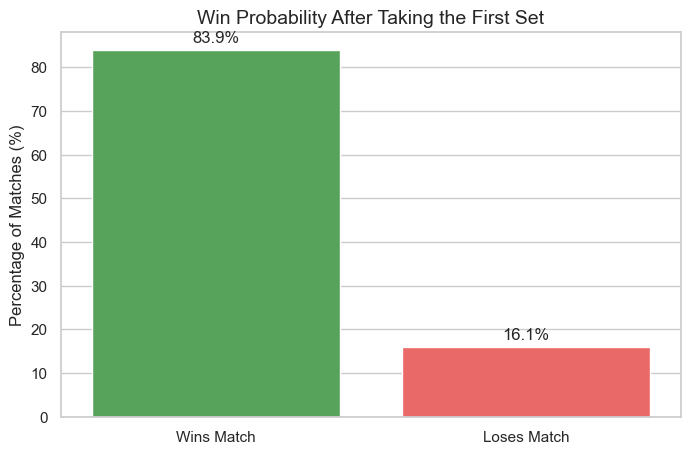

In [ ]:

sns.set_theme(style="whitegrid")


plt.figure(figsize=(8, 5))
data = df['first_set_winner_won_match'].value_counts(normalize=True) * 100
ax = sns.barplot(x=['Wins Match', 'Loses Match'], y=data.values, palette=['#4CAF50', '#FF5252'])
plt.title('Win Probability After Taking the First Set', fontsize=14)
plt.ylabel('Percentage of Matches (%)')


for i, v in enumerate(data.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', va='bottom')

plt.savefig('visual1_first_set_advantage.png')
plt.show()

## 6. Key Insights

### Summary Statistics
- **First Set Winners Who Won Match**: Percentage of matches won after taking first set
- **First Set Winners Who Lost Match**: Comebacks from first-set deficits
- **Comeback Rate**: Probability of a first-set loser winning the match

### Conclusions
This analysis reveals the strength of first-set momentum in professional tennis and validates whether early dominance translates to match victory.